In [2]:
"""
Name: Module 4 KMeans 2D Example.py
Course: Data Preparation and Analysis
Created Date: September 30, 2023
Author: Ming-Long Lam, Ph.D.g
Organization: Illinois Institute of Technology
"""

import matplotlib.pyplot as plt
import numpy
import pandas
import random
import sys

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)

pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)

pandas.options.display.float_format = '{:,.10f}'.format

from sklearn import cluster, metrics

trainData = pandas.DataFrame({'x': [2.0, 4.0, 2.0, 4.0, 6.0, 8.0, 6.0, 8.0, 4.5, 5.5, 5.5, 4.5],
                              'y': [11.0, 11.0, 9.0, 9.0, 11.0, 11.0, 9.0, 9.0, 5.5, 5.5, 4.5, 4.5]})

feature_name = trainData.columns


In [12]:

# Specify the maximum number of clusters
max_nCluster = 3

nClusters = []
Elbow = []
Silhouette = []
TotalWCSS = []

# Try each number of cluster
for k in range(max_nCluster):
#    print('k value: ' + str(k))
#    print('Number of Clusters: ' + str(k + 1))

   # Train a k-means algorithm
   nCluster = k + 1
   objCluster = cluster.KMeans(n_clusters = nCluster, init = 'random',
                               n_init = 10, random_state = 5712023)
   member = objCluster.fit_predict(trainData)

   centroid = pandas.DataFrame(objCluster.cluster_centers_, columns = feature_name)
   print('Centroids for nof cluster = ' + str(k+1) + ':')
   print(centroid)

   # Calculate the Silhouette Index
   if (nCluster > 1):
       S = metrics.silhouette_score(trainData, member)
   else:
       S = numpy.nan

   # Calculate the Within-Cluster Sum of Squares and Cluster sizes
   WCSS = numpy.zeros(nCluster)
   nSize = numpy.zeros(nCluster)

   for i in range(nCluster):
      # this will return all value that are assigned to cluster i
      subset = trainData[member == i]
      
      # centroid is mean of all values in that cluster, so the distance is the difference between each point and the centroid
      diff = subset - centroid.iloc[i]
      # cluster size is the number of points in that cluster
      nSize[i] = diff.shape[0]

      # summ of column and then sum of sum of columns to get the total distance for that cluster
      WCSS[i] = numpy.square(diff).sum().sum()

   # Calculate the Elbow values
   E = numpy.sum(numpy.divide(WCSS, nSize))
   T = numpy.sum(WCSS)

   nClusters.append(nCluster)
   Elbow.append(E)
   Silhouette.append(S)
   TotalWCSS.append(T)




Centroids for nof cluster = 1:
             x            y
0 5.0000000000 8.3333333333
Centroids for nof cluster = 2:
             x             y
0 5.0000000000 10.0000000000
1 5.0000000000  5.0000000000
Centroids for nof cluster = 3:
             x             y
0 7.0000000000 10.0000000000
1 5.0000000000  5.0000000000
2 3.0000000000 10.0000000000


In [6]:
diff

,x,y
0,-3.0000000000,2.6666666667
1,-1.0000000000,2.6666666667
2,-3.0000000000,0.6666666667
3,-1.0000000000,0.6666666667
4,1.0000000000,2.6666666667
5,3.0000000000,2.6666666667
6,1.0000000000,0.6666666667
7,3.0000000000,0.6666666667
8,-0.5000000000,-2.8333333333
9,0.5000000000,-2.8333333333


In [8]:
trainData.mean()

x   5.0000000000
y   8.3333333333
dtype: float64

In [ ]:
objCluster.labels_

array([2, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1], dtype=int32)

In [ ]:
plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, TotalWCSS, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Total Within-Cluster Sum of Squares')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, Elbow, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Elbow Value')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, Silhouette, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Index')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

result_df = pandas.DataFrame({'N Cluster': nClusters, 'Total WCSS': TotalWCSS,
                              'Elbow': Elbow, 'Silhouette': Silhouette})

In [17]:
import numpy as np
from sklearn.metrics import silhouette_score

# 1. Setup the data parameters
N = 39
K = 20

# 2. Generate the feature data X (reshaped for sklearn)
# X contains integers from 0 to N-1
X = np.array(range(N)).reshape(-1, 1)

# 3. Generate the cluster labels based on the modulus operator
# label = x % K
labels = np.array([x % K for x in range(N)])

# 4. Calculate the Silhouette Score
score = silhouette_score(X, labels, metric='euclidean')

print(f"Dataset Size (N): {N}")
print(f"Number of Clusters (K): {K}")
print(f"Silhouette Score: {score:.4f}")

Dataset Size (N): 39
Number of Clusters (K): 20
Silhouette Score: -0.6000


In [18]:
labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18])

In [30]:
import pandas as pd
df = pd.read_csv(r'data\TwoFeatures.csv')
df

# Rescale x1 and x2 individually such that the resulting variables have a minimum of zero and a maximum of ten. Use the resulting variables for clustering.

df['x1_rescaled'] = 10 * (df['x1'] - df['x1'].min()) / (df['x1'].max() - df['x1'].min())
df['x2_rescaled'] = 10 * (df['x2'] - df['x2'].min()) / (df['x2'].max() - df['x2'].min())
df_rc = df[['x1_rescaled', 'x2_rescaled']]
df_rc

,x1_rescaled,x2_rescaled
0,8.3676975945,2.8788232207
1,1.5292096220,8.7615534886
2,1.9072164948,1.9412776628
3,7.0446735395,1.3028836341
4,8.1443298969,1.7167682305
...,...,...
195,1.0824742268,1.3597399189
196,8.6082474227,3.2298743330
197,3.2130584192,7.4726652477
198,2.5773195876,1.3265008601


In [31]:
trainData = df_rc.copy()
# Specify the maximum number of clusters
max_nCluster = 10

nClusters = []
Elbow = []
Silhouette = []
TotalWCSS = []

# Try each number of cluster
for k in range(max_nCluster):
#    print('k value: ' + str(k))
#    print('Number of Clusters: ' + str(k + 1))

   # Train a k-means algorithm
   nCluster = k + 1
   objCluster = cluster.KMeans(n_clusters = nCluster, init = 'random',
                               n_init = 10, random_state = 5712023)
   member = objCluster.fit_predict(trainData)

   centroid = pandas.DataFrame(objCluster.cluster_centers_, columns = feature_name)
#    print('Centroids for nof cluster = ' + str(k+1) + ':')
#    print(centroid)

   # Calculate the Silhouette Index
   if (nCluster > 1):
       S = metrics.silhouette_score(trainData, member)
   else:
       S = numpy.nan

   # Calculate the Within-Cluster Sum of Squares and Cluster sizes
   WCSS = numpy.zeros(nCluster)
   nSize = numpy.zeros(nCluster)

   for i in range(nCluster):
      # this will return all value that are assigned to cluster i
      subset = trainData[member == i]
      
      # centroid is mean of all values in that cluster, so the distance is the difference between each point and the centroid
      diff = subset - centroid.iloc[i]
      # cluster size is the number of points in that cluster
      nSize[i] = diff.shape[0]

      # summ of column and then sum of sum of columns to get the total distance for that cluster
      WCSS[i] = numpy.square(diff).sum().sum()

   # Calculate the Elbow values
   E = numpy.sum(numpy.divide(WCSS, nSize))
   T = numpy.sum(WCSS)

   nClusters.append(nCluster)
   Elbow.append(E)
   Silhouette.append(S)
   TotalWCSS.append(T)




In [ ]:
print

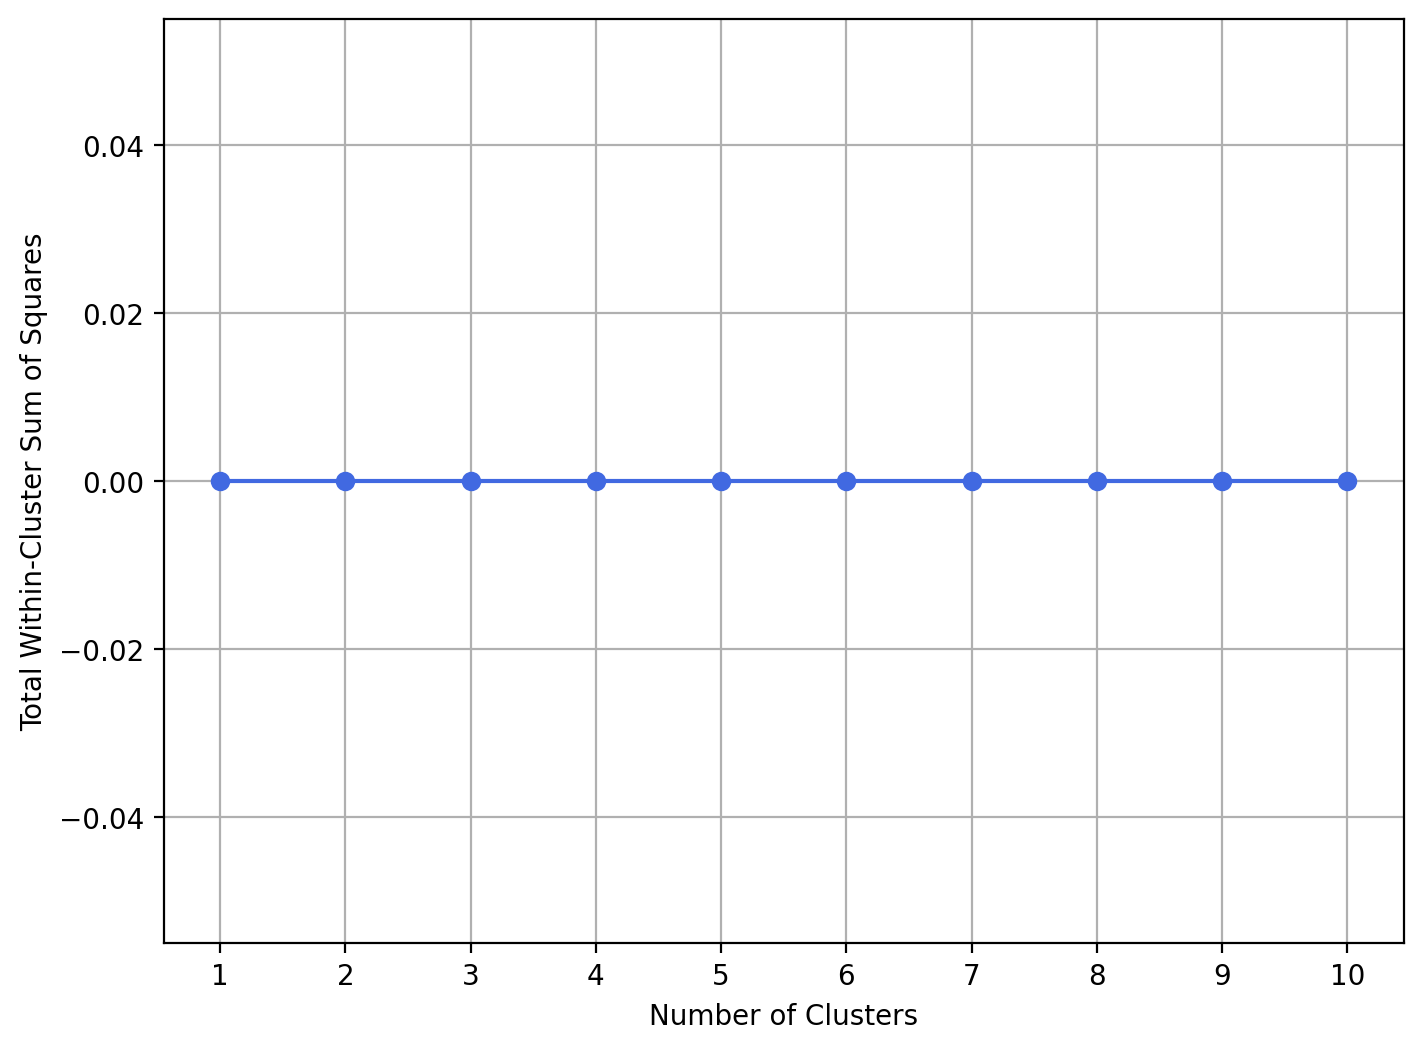

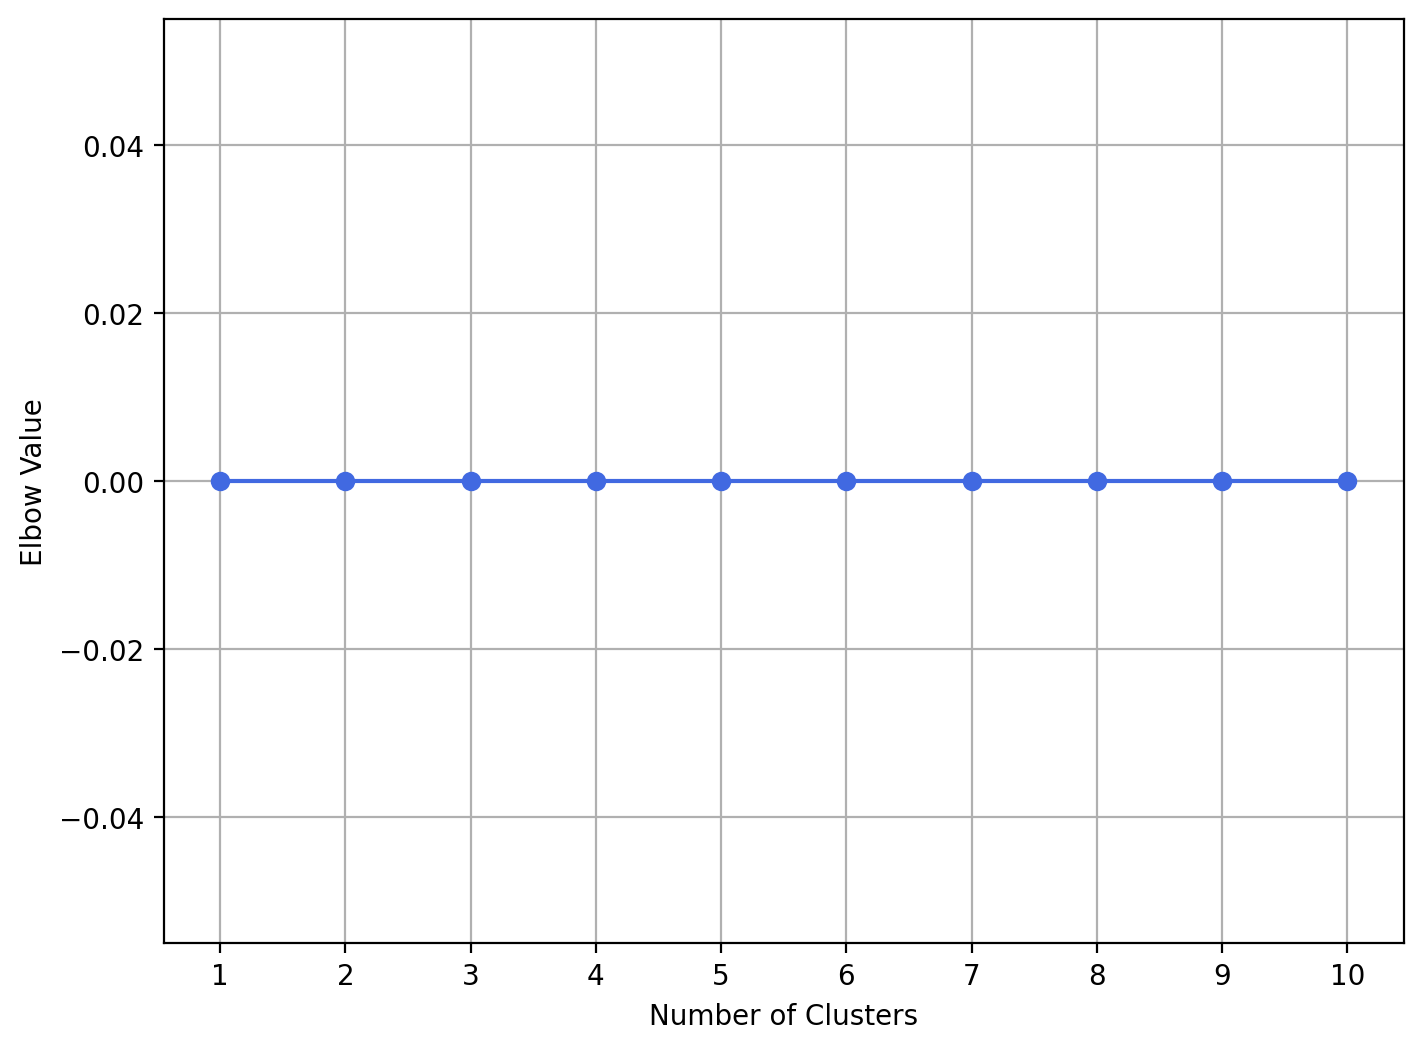

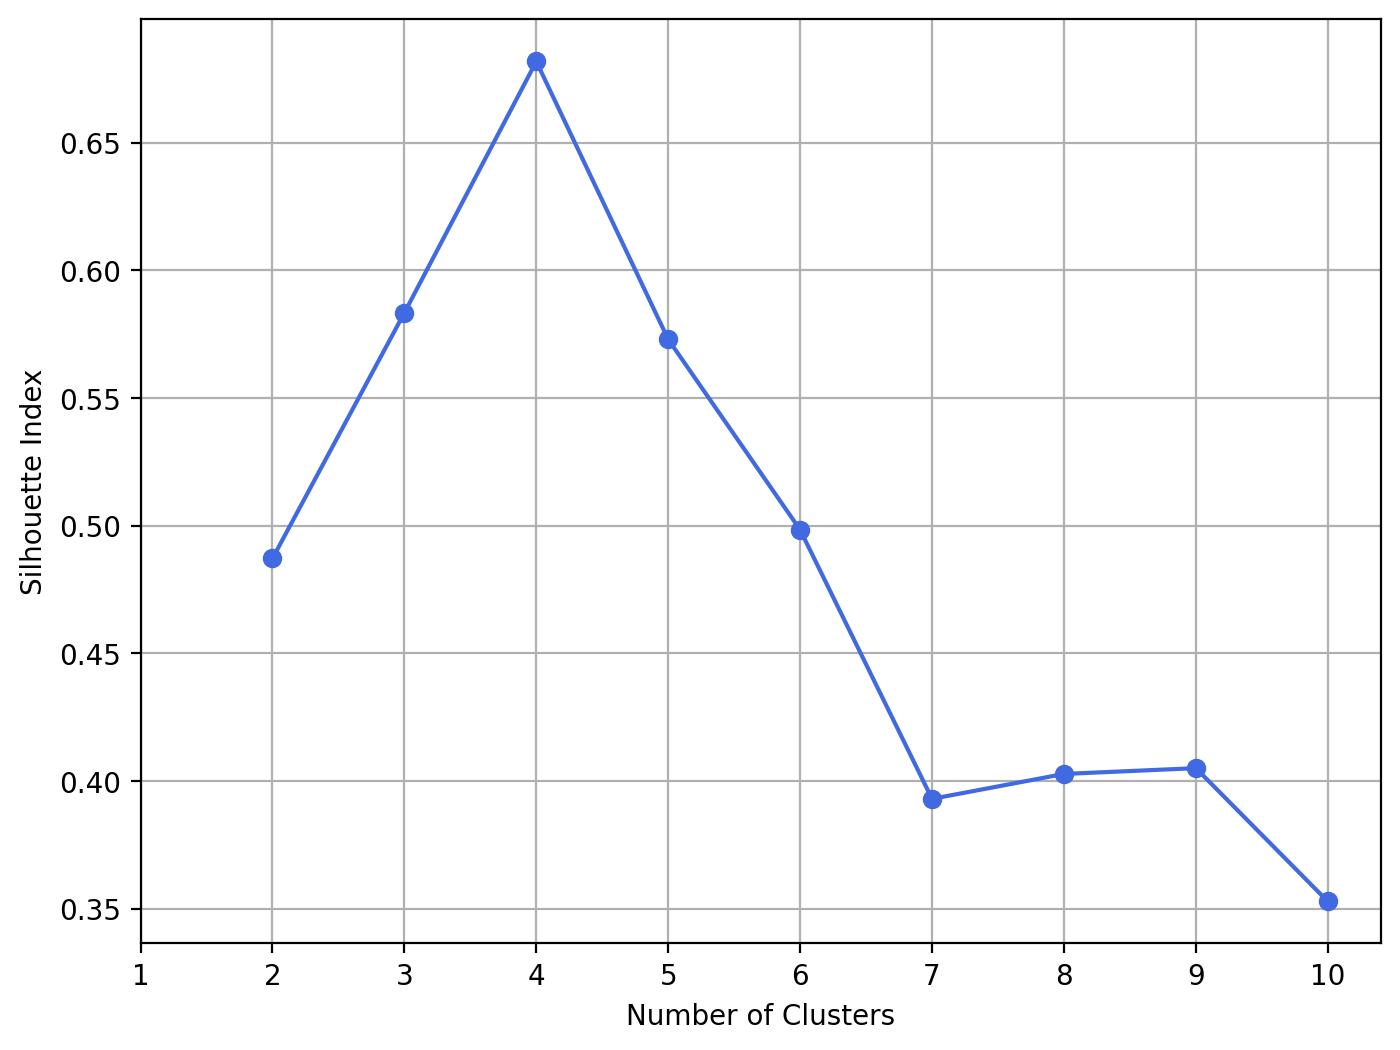

In [32]:
plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, TotalWCSS, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Total Within-Cluster Sum of Squares')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, Elbow, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Elbow Value')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

plt.figure(figsize = (8,6), dpi = 200)
plt.plot(nClusters, Silhouette, marker = 'o', color = 'royalblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Index')
plt.xticks(range(1,max_nCluster+1))
plt.grid()
plt.show()

result_df = pandas.DataFrame({'N Cluster': nClusters, 'Total WCSS': TotalWCSS,
                              'Elbow': Elbow, 'Silhouette': Silhouette})

In [28]:
result_df

,N Cluster,Total WCSS,Elbow,Silhouette
0,1,0.0000000000,0.0000000000,NaN
1,2,0.0000000000,0.0000000000,0.8296063193
2,3,0.0000000000,0.0000000000,0.6557298195
3,4,0.0000000000,0.0000000000,0.5597169540
4,5,0.0000000000,0.0000000000,0.5468796169
5,6,0.0000000000,0.0000000000,0.5249669442
6,7,0.0000000000,0.0000000000,0.5396170590
7,8,0.0000000000,0.0000000000,0.5369202308
8,9,0.0000000000,0.0000000000,0.5420349264
9,10,0.0000000000,0.0000000000,0.5435294915
